In [1]:
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

from pymargins import GComputation  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(13)
n_entities, n_periods = 200, 6
entity = np.repeat(np.arange(n_entities), n_periods)
period = np.tile(np.arange(n_periods), n_entities)
df = pd.DataFrame({
    "entity": entity, "period": period,
    "x": rng.normal(0, 1, n_entities * n_periods),
    "alpha_i": np.repeat(rng.normal(0, 1, n_entities), n_periods),
}).set_index(["entity", "period"])
df["y"] = 1.0 + 0.6 * df["x"] + df["alpha_i"] + rng.normal(0, 0.5, len(df))

fit = PanelOLS(df["y"], df[["x"]], entity_effects=True).fit(
    cov_type="clustered", cluster_entity=True
)

In [2]:
m = GComputation(fit, at="overall", scale="identity")
print(m.dydx("x").summary())

           Graph Result (delta, level=0.95)           
   estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------
x    0.6004   0.0157  38.2756  0.000    0.5696, 0.6311

n = 1200
Delta-vs-sim disagreement: 0.350%
plan 3804f4c@1 | κ = 0.000


In [3]:
print(m.predict(atexog={"x": [-1.0, 0.0, 1.0]}).summary())

              Graph Result (delta, level=0.95)              
        estimate  std err         z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
x=-1.0   -0.5996   0.0156  -38.3252  0.000  -0.6303, -0.5690
x=0.0     0.0000   0.0000    0.0000  1.000    0.0000, 0.0000
x=1.0     0.5996   0.0156   38.3252  0.000    0.5690, 0.6303

n = 1200
Delta-vs-sim disagreement: inf%
plan 3804f4c@1 | κ = max inf


[Text(0.5, 0, 'x'), Text(0, 0.5, 'Predicted y')]

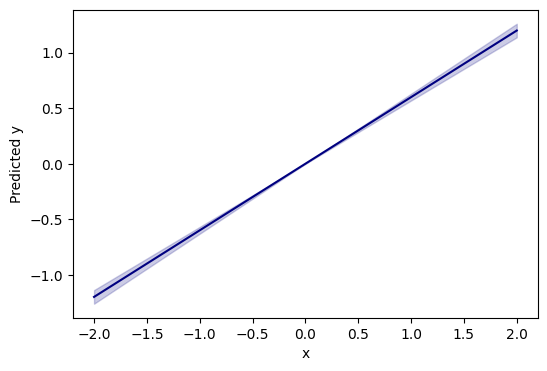

In [4]:
import matplotlib.pyplot as plt

x_vals = np.linspace(-2, 2, 50)
res = m.predict(atexog={"x": x_vals})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_plot["x"], df_plot["estimate"], color="navy")
ax.fill_between(
    df_plot["x"], df_plot["ci_lower"], df_plot["ci_upper"],
    alpha=0.2, color="navy"
)
ax.set(xlabel="x", ylabel="Predicted y")